In [1]:
# Description: Plot Figure 4 (Shelf edge cross-isobath geostrophic velocity and nitrate time-means and seasonal anomalies)
#               and Figure 5 (Cross-shelf edge nitrate transport and spatial nitrate distribution)
# Author:      André Palóczy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from xarray import open_dataset
from pandas import DataFrame, read_json
from cmocean.cm import balance, delta, matter, tarn_r

from matplotlib.gridspec import GridSpec
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
proj = ccrs.PlateCarree()
from cartopy.feature import LAND

## Define file paths

In [3]:
def near2(x, y, x0, y0):
    dr2 = (x - x0)**2 + (y - y0)**2
    return int(np.nanargmin(dr2))

d = np.load("../proc/isobath_200m.npz")
xi, yi, di = d["xi"], d["yi"], d["di"]
xseg0, yseg0 = np.loadtxt("../proc/segment_latitudes_wei_etal2024.txt", unpack=True)
fseg = [near2(xi, yi, xseg0[i], yseg0[i]) for i in range(len(yseg0))]

# Clip start/end to fit segments.
xseg, yseg = xi[fseg], yi[fseg]
dibound = di[fseg]
txt_segs = ["AS", "CSS", "PSBS", "MS", "HS", "WSS", "NENSS"]

# Also clip 100 m isobath just for plotting.
d = np.load("../proc/isobath_100m.npz")
xi100, yi100 = d["xi_ext"], d["yi_ext"]
fclip100l = near2(xi100, yi100, xseg0[0], yseg0[0])
fclip100r = near2(xi100, yi100, xseg0[-1], yseg0[-1]) + 1
xi100, yi100 = xi100[fclip100l:fclip100r], yi100[fclip100l:fclip100r]

def annotate_segments(axi, dibound=dibound, txt_segs=txt_segs, ytxt=-190):
    for i in range(len(txt_segs)):
        xtxt = 0.5*(dibound[i] + dibound[i+1])
        axi.text(xtxt, ytxt, txt_segs[i], ha="center", va="center", fontsize=13, color="k", bbox=dict(boxstyle="round,pad=0.3", fc="w", ec="k", lw=1))

def annotate_segments2(axi, dibound=dibound, txt_segs=txt_segs, ytxt=-100, fontsize=14, txtcol="k", txtweight="black"):
    for i in range(len(txt_segs)):
        xtxt = 0.5*(dibound[i] + dibound[i+1])
        axi.text(xtxt, ytxt, txt_segs[i], ha="center", va="center", rotation=90, fontsize=fontsize, color=txtcol, fontweight=txtweight, zorder=99999)

f = "../proc/alongisob_seasonal_WOA23_200m.nc"

ds = open_dataset(f)
ug, N, ugN = ds["ug"], ds["N"], ds["ugN"]
rho = ds["rho"]
ug_annual = ug.sel(t="annual")
ug_bc_annual = ug_annual - ug_annual.sel(z=0)
N_annual = N.sel(t="annual")

x, z = ds["x"].values, ds["z"].values

ugmax = 5 # [cm/s]
dug = 2.5 # [cm/s]
uglevs = np.concatenate([np.arange(-ugmax, dug, dug), np.arange(dug, ugmax + dug, dug)])
ugmax_diff = 0.5 # [cm/s]

nlevsc = 10
Dmi, Dma = 25.0, 27.5 # [kg/m3]
Dlevsc = np.linspace(Dmi, Dma, num=nlevsc)
Dccl = Dlevsc[::2]

# Nmin, Nmax = 2, 12 # [mmol/m3]
Nmin, Nmax = 1, 13 # [mmol/m3]

Nlevs = np.arange(Nmin, Nmax+2, 2)
N_diff = 5 # [mmol/m3]

ts = ds["t"].values
ts_ssn = ts[1:]

getfattr: Removing leading '/' from absolute path names


## Plot Figure 4.

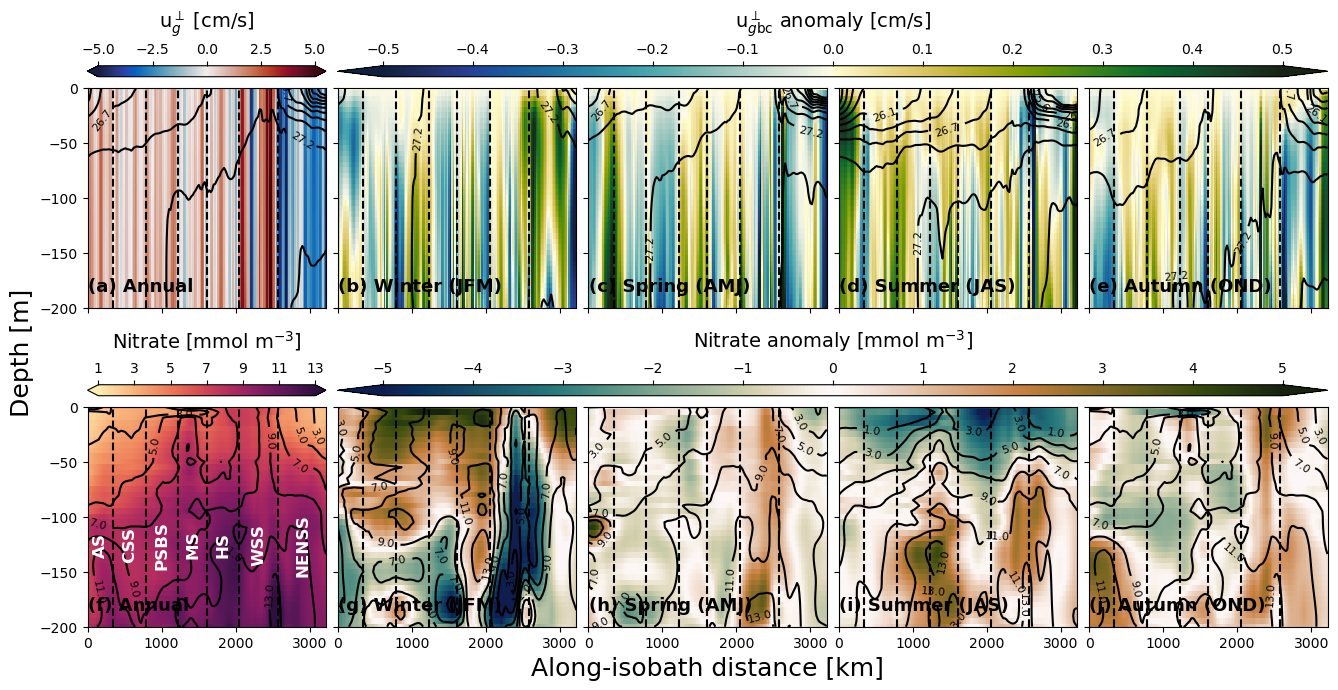

In [4]:
figsize = (16, 7)

css = []
nrows = 2
ncols = 5
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=figsize)

for j in range(nrows):
    axj = axs[j]
    for i in range(ncols):
        ti = ts[i]
        axi = axj[i]
        rhoi = rho.sel(t=ti)
        ugi, Ni = ug.sel(t=ti), N.sel(t=ti)

        if i>0: # Baroclinic ug seasonal anomaly.
            ugi_bc = ugi - ugi.sel(z=0)
            ugi = ugi_bc - ug_bc_annual
            ugcmap = delta
            ugmaxi = ugmax_diff
            Ncmap = tarn_r
            Nmini, Nmaxi = -N_diff, N_diff
            Ni0 = Ni.copy()
            Ni = Ni - N_annual
        else: # Absolute ug.
            ugcmap = balance
            ugmaxi = ugmax
            Ncmap = matter
            Nmini, Nmaxi = Nmin, Nmax

        if j==0:
            csi = axi.pcolormesh(x, z, ugi, vmin=-ugmaxi, vmax=ugmaxi, cmap=ugcmap)
            cc = axi.contour(x, z, rhoi, levels=Dlevsc, colors="k")
            axi.clabel(cc, levels=Dccl, fmt="%1.1f", fontsize=8)
        elif j==1:
            csi = axi.pcolormesh(x, z, Ni, vmin=Nmini, vmax=Nmaxi, cmap=Ncmap)
            cc = axi.contour(x, z, Ni0, levels=Nlevs, colors="k")
            axi.clabel(cc, levels=Nlevs, fmt="%1.1f", fontsize=8)
        css.append(csi)

axs = axs.ravel()

axs[0].set_xlim(0, x[-1])
axs[0].set_ylim(-200, 0)
axs[0].set_ylabel(r"Depth [m]", y=-0.2, fontsize=18)
axs[-3].set_xlabel(r"Along-isobath distance [km]", fontsize=18)
for axi in axs:
    _ = [axi.axvline(x=dd, color="k", linestyle="--", linewidth=1.5, zorder=2) for dd in dibound[1:-1]]
annotate_segments2(axs[5], dibound=dibound, txt_segs=txt_segs, ytxt=-125, fontsize=12, txtcol="w", txtweight="bold")

l, r, w, h = 0, 1.05, 1, 0.05
w2 = 4.15

dugd = 0.1
dN_diff = 1
udiff_levs = np.concatenate([np.arange(-ugmax_diff, dugd, dugd), np.arange(dugd, ugmax_diff + dugd, dugd)])
Ndiff_levs = np.arange(-N_diff, N_diff + dN_diff, dN_diff)

ax1, ax2, ax3, ax4, ax5 = axs[:5]
ax6, ax7, ax8, ax9, ax10 = axs[5:]

cax = ax1.inset_axes([l, r, w, h])
cb = fig.colorbar(css[0], cax=cax, orientation="horizontal", extend="both")
cb.set_label(r"u$_g^\perp$ [cm/s]", fontsize=14, labelpad=10)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks(uglevs)

cax = ax6.inset_axes([l, r, w, h])
cb = fig.colorbar(css[5], cax=cax, orientation="horizontal", extend="both")
cb.set_label(r"Nitrate [mmol m$^{-3}$]", fontsize=14, labelpad=10)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks(Nlevs)

cax = ax2.inset_axes([l, r, w2, h])
cb = fig.colorbar(css[1], cax=cax, orientation="horizontal", extend="both")
cb.set_label(r"u$_{g\text{bc}}^\perp$ anomaly [cm/s]", fontsize=14, labelpad=10)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks(udiff_levs)

cax = ax7.inset_axes([l, r, w2, h])
cb = fig.colorbar(css[6], cax=cax, orientation="horizontal", extend="both")
cb.set_label(r"Nitrate anomaly [mmol m$^{-3}$]", fontsize=14, labelpad=10)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks(Ndiff_levs)

letters = list("abcdefghij")

xlett, ylett = 0.001, 0.1
for i, axi in enumerate(axs):
    txt = "(" + letters[i] + ")"
    if i==0 or i==5:
        txt += " Annual"
    elif i==1 or i==6:
        txt += " Winter (JFM)"
    elif i==2 or i==7:
        txt += " Spring (AMJ)"
    elif i==3 or i==8:
        txt += " Summer (JAS)"
    elif i==4 or i==9:
        txt += " Autumn (OND)"

    axi.text(xlett, ylett, txt, color="k", fontweight="black", ha="left", va="center", fontsize=13, transform=axi.transAxes, zorder=9999)

fig.subplots_adjust(hspace=0.45, wspace=0.05);

In [5]:
fig.savefig("fig4.png", bbox_inches="tight", dpi=200)

## Calculate segment-averaged depth-integrated nitrate transports and nitrate transport convergences.

In [6]:
Niz_segs_ti = dict()
ugNizint_segs_ti = dict()
Niz_segs = dict()
ugNizint_segs = dict()
ugiz_segs = dict()

nx = Ni.sizes["x"]
zflip = -Ni["z"].values
dz = np.gradient(zflip)[:, np.newaxis]
xx, zz = np.meshgrid(x, zflip)
ipts = (zz, xx)
for i in range(0, 5):
    ti = ts[i]
    # print("===")
    # print(ti)
    # print("===")
    ugi, Ni = ug.sel(t=ti), N.sel(t=ti)

    # Calculate cross-isobath geostrophic nitrate flux ug*N.
    ugNi = ugN.sel(t=ti) # [mmol/m2/s]
    Niz = Ni.mean("z").values # Depth-averaged nitrate concetration [mmol/m3]
    ugNizint = (ugNi*dz).sum("z").values # Integrated ug*N [mmol/m/s], not segment-averaged yet.
    ugiz = (1e-2 * ugi).mean("z").values # Depth-averaged ug [m/s]

    # Segment-averaged depth-integrated ug*N and depth-avg N.
    Niz_segs_ti = dict()
    ugNizint_segs_ti = dict()
    ugiz_segs_ti = dict()
    for n in range(len(fseg) - 1):
        seg = txt_segs[n]
        fl, fr = fseg[n], fseg[n+1]
        dx = np.diff(di[fl:fr])*1e3
        Lx = dx.sum()

        Niz_aux = Niz[fl:fr]
        Niz_aux = 0.5*(Niz_aux[1:] + Niz_aux[:-1])
        Niz_segavg = np.nansum(Niz_aux*dx)/Lx # mmol/m3

        ugNizint_aux = ugNizint[fl:fr]
        ugNizint_aux = 0.5*(ugNizint_aux[1:] + ugNizint_aux[:-1])
        ugNizint_segavg = np.nansum(ugNizint_aux*dx)/Lx # mmol/m/s

        ugiz_aux = ugiz[fl:fr]
        ugiz_aux = 0.5*(ugiz_aux[1:] + ugiz_aux[:-1])
        ugiz_segavg = np.nansum(ugiz_aux*dx)/Lx # m/s

        # print(ti + " - Segment: " + seg + " -->    N = " + "%1.1f mmol/m3"%Niz_segavg)
        print(ti + " - Segment: " + seg + " --> ug*N = " + "%1.1f mmol/m/s"%ugNizint_segavg)
        Niz_segs_ti.update({seg:Niz_segavg})
        ugNizint_segs_ti.update({seg:ugNizint_segavg})
        ugiz_segs_ti.update({seg:ugiz_segavg})

    Niz_segs.update({ti:Niz_segs_ti})
    ugNizint_segs.update({ti:ugNizint_segs_ti})
    ugiz_segs.update({ti:ugiz_segs_ti})

annual - Segment: AS --> ug*N = 14.4 mmol/m/s
annual - Segment: CSS --> ug*N = 6.6 mmol/m/s
annual - Segment: PSBS --> ug*N = 16.2 mmol/m/s
annual - Segment: MS --> ug*N = 5.8 mmol/m/s
annual - Segment: HS --> ug*N = 5.5 mmol/m/s
annual - Segment: WSS --> ug*N = 27.4 mmol/m/s
annual - Segment: NENSS --> ug*N = -37.5 mmol/m/s
JFM - Segment: AS --> ug*N = 14.8 mmol/m/s
JFM - Segment: CSS --> ug*N = 6.4 mmol/m/s
JFM - Segment: PSBS --> ug*N = 15.7 mmol/m/s
JFM - Segment: MS --> ug*N = 5.4 mmol/m/s
JFM - Segment: HS --> ug*N = 7.3 mmol/m/s
JFM - Segment: WSS --> ug*N = 18.4 mmol/m/s
JFM - Segment: NENSS --> ug*N = -34.5 mmol/m/s
AMJ - Segment: AS --> ug*N = 15.9 mmol/m/s
AMJ - Segment: CSS --> ug*N = 6.5 mmol/m/s
AMJ - Segment: PSBS --> ug*N = 10.9 mmol/m/s
AMJ - Segment: MS --> ug*N = 8.3 mmol/m/s
AMJ - Segment: HS --> ug*N = 8.1 mmol/m/s
AMJ - Segment: WSS --> ug*N = 29.7 mmol/m/s
AMJ - Segment: NENSS --> ug*N = -37.8 mmol/m/s
JAS - Segment: AS --> ug*N = 15.3 mmol/m/s
JAS - Segment: CSS

## Read in shelf nitrate concentrations from NSBC.

In [7]:
N_fileout = "../proc/Nmeans_shelf-NSBC.json"
Nmeans_shelf = read_json(N_fileout)
Nmeans_shelf_annual = Nmeans_shelf.mean()
Nmeans_shelf = Nmeans_shelf.to_dict()
Nmeans_shelf_annual["PSBS"] = np.nan # PSBC has a valid mean only for AMJ, NaN out the annual average.

## Plot Figure 5.

annual - (AS, CSS, PSBS, MS, HS, WSS, NENSS) --> -d(ug*N)/dx = (nan, 1.1, nan, 0.6, 0.9, 3.7, -4.0) x 1e-7 mmol/m3/s
JFM - (AS, CSS, PSBS, MS, HS, WSS, NENSS) --> -d(ug*N)/dx = (nan, 0.5, nan, 0.3, 1.0, -2.8, 3.4) x 1e-7 mmol/m3/s
AMJ - (AS, CSS, PSBS, MS, HS, WSS, NENSS) --> -d(ug*N)/dx = (nan, 0.9, 2.6, 1.0, 1.4, 6.7, -7.3) x 1e-7 mmol/m3/s
JAS - (AS, CSS, PSBS, MS, HS, WSS, NENSS) --> -d(ug*N)/dx = (nan, 2.2, nan, nan, 1.1, 6.7, -6.8) x 1e-7 mmol/m3/s
OND - (AS, CSS, PSBS, MS, HS, WSS, NENSS) --> -d(ug*N)/dx = (nan, 1.1, nan, nan, 0.2, 3.9, -5.4) x 1e-7 mmol/m3/s


getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names


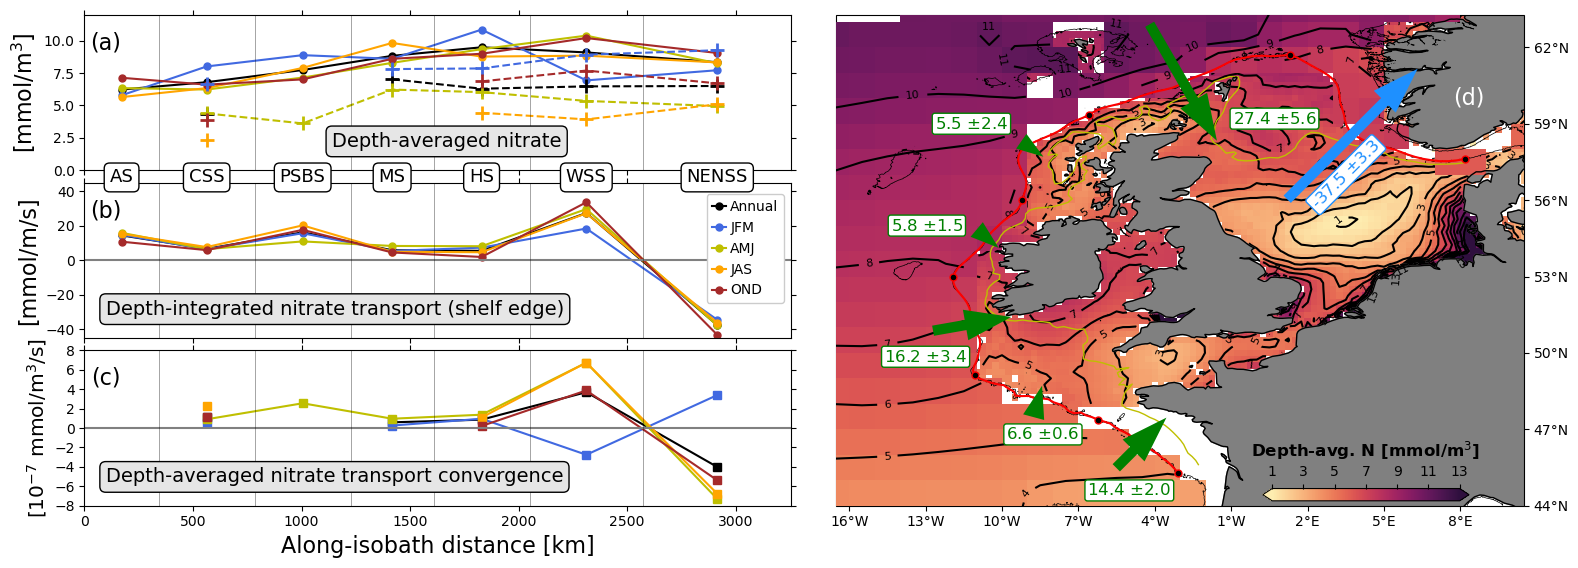

In [8]:
fac = 0.85
fig = plt.figure(figsize=(22*fac, 7.5*fac))

gs = GridSpec(3, 2, wspace=0.05, hspace=0.08)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[:, -1], projection=proj)

Nxdiff_shelfocean = dict()
cols = dict(annual="k", JFM="royalblue", AMJ="y", JAS="orange", OND="brown")
dim = 0.5*(dibound[1:] + dibound[:-1])
for ti in ts:
    Niz_ssn = np.array([])
    Niz_ssn_shelf = np.array([])
    ugNizint_ssn = np.array([])
    dNauxs = dict()
    for seg in txt_segs:
        Niz_ssn = np.append(Niz_ssn, Niz_segs[ti][seg])
        ugNizint_ssn = np.append(ugNizint_ssn, ugNizint_segs[ti][seg])

        # Shelf nitrate concentrations.
        if seg=="AS":
            Niz_ssn_shelf = np.append(Niz_ssn_shelf, np.nan)
            dNaux = np.nan
        else:
            if ti=="annual":
                Niz_ssn_shelf = np.append(Niz_ssn_shelf, Nmeans_shelf_annual[seg])
                dNaux = Nmeans_shelf_annual[seg] - Niz_segs[ti][seg]
            else:
                Niz_ssn_shelf = np.append(Niz_ssn_shelf, Nmeans_shelf[seg][ti])
                dNaux = Nmeans_shelf[seg][ti] - Niz_segs[ti][seg]

        dNauxs.update({seg:dNaux})
    dNauxs_array = np.array(list(dNauxs.values()))

    # Save Nshelf - Nshelfedge.
    Nxdiff_shelfocean.update({ti:dNauxs}) # Non - Noff for cross-shelf nitrate transport divergence estimates.

    if ti=="annual":
        tii = ti.capitalize()
    else:
        tii = ti

    ugiz_ssn = np.array(list(ugiz_segs[ti].values())) # [m/s] Depth-avg and segment-avg x-shelf velocity.
    Lxshelf = 100e3 # [m], typical cross-shelf scale.

    ugNxizint_ssn = -ugiz_ssn*dNauxs_array/Lxshelf # [mmol/m3/s], minus sign for nitrate convergence.
    ugNxizint_ssn = ugNxizint_ssn*1e7 # [1e-7 mmol/m3/s]
    aux_str = "("
    for ugNx_aux in ugNxizint_ssn:
        aux_str = aux_str + "%1.1f"%ugNx_aux + ", "
    aux_str = aux_str[:-2] + ")"
    print(ti + " - (AS, CSS, PSBS, MS, HS, WSS, NENSS) --> -d(ug*N)/dx = " + "%s x 1e-7 mmol/m3/s"%aux_str)

    col = cols[ti]
    ax1.plot(dim, Niz_ssn, color=col, marker="o", markersize=5, zorder=1)
    ax1.plot(dim, Niz_ssn_shelf, color=col, linestyle="dashed", marker="+", markersize=10, mew=2, zorder=2)
    ax2.plot(dim, ugNizint_ssn, color=col, marker="o", markersize=5, label=r"%s"%tii)
    ax3.plot(dim, ugNxizint_ssn, color=col, marker="s", markersize=6)

ax1.tick_params(axis='x', which='both', labelbottom=False)
ax2.tick_params(axis='x', which='both', labelbottom=False)
_ = [ax1.tick_params(axis='both', which='both', left=True, bottom=True, right=True, top=True)]
_ = [ax2.tick_params(axis='both', which='both', left=True, bottom=True, right=True, top=True)]
_ = [ax3.tick_params(axis='both', which='both', left=True, bottom=True, right=True, top=True)]
ax1.tick_params(axis='both', direction='out'); ax2.tick_params(axis='both', direction='out'); ax3.tick_params(axis='both', direction='out')
ax2.axhline(color="gray"); ax3.axhline(color="gray")
ax1.set_xlim(di[0], di[-1]); ax2.set_xlim(di[0], di[-1]); ax3.set_xlim(di[0], di[-1])
ax1.set_ylim(0, 12); ax2.set_ylim(-45, 45)

uNdivmax = 8
ax3ytks = np.arange(-uNdivmax, uNdivmax + 2, 2)
ax3.set_ylim(-uNdivmax, uNdivmax)
ax3.set_yticks(ax3ytks)

annotate_segments(ax2, dibound=dibound, txt_segs=txt_segs, ytxt=48)
_ = [ax1.axvline(x=dd, color="k", linestyle="-", linewidth=0.5, alpha=0.5, zorder=2) for dd in dibound[1:-1]]
_ = [ax2.axvline(x=dd, color="k", linestyle="-", linewidth=0.5, alpha=0.5, zorder=2) for dd in dibound[1:-1]]
_ = [ax3.axvline(x=dd, color="k", linestyle="-", linewidth=0.5, alpha=0.5, zorder=2) for dd in dibound[1:-1]]
ax2.legend(ncols=1, loc=(0.88, 0.225), framealpha=1, handlelength=1, handletextpad=0.3, fontsize=10)

xtxt1, xtxt2, xtxt3 = 0.35, 0.03, 0.03
ytxt1, ytxt2, ytxt3 = 0.15, 0.15, 0.15
props = dict(boxstyle="round", facecolor=(0.9, 0.9, 0.9))

txt1 = r"Depth-averaged nitrate"
txt2 = r"Depth-integrated nitrate transport (shelf edge)"
txt3 = r"Depth-averaged nitrate transport convergence"

ax1.text(xtxt1, ytxt1, txt1, transform=ax1.transAxes, fontsize=14, color="k", bbox=props)
ax2.text(xtxt2, ytxt2, txt2, transform=ax2.transAxes, fontsize=14, color="k", bbox=props)
ax3.text(xtxt3, ytxt3, txt3, transform=ax3.transAxes, fontsize=14, color="k", bbox=props)

ax1.set_ylabel(r"[mmol/m$^3$]", fontsize=16)
ax2.set_ylabel(r"[mmol/m/s]", fontsize=16)
ax3.set_ylabel(r"[$10^{-7}$ mmol/m$^3$/s]", fontsize=14.5)
ax3.set_xlabel(r"Along-isobath distance [km]", fontsize=16)

rho0 = 1027.5 # [kg/m3] - Reference density at 0 dbar.

# NSBC Nitrate in the upper 200 m.
max_interp_err = 0.5 # Max fractional interpolation error threshold for NSBC nitrate.

fNshelf = "../data/nsbc/level3/all_data_mean/NSBC_Level3_nitrate__UHAM_ICDC__v1.1__0.25x0.25deg__OAN__all_data_mean__1960_2014.nc"
ds = open_dataset(fNshelf, decode_times=False)
Nshelf0 = ds["nitrate_mean"].squeeze()
Nshelf = Nshelf0.sel(depth=slice(0, 200))
mskerr_interp = ds["nitrate_relative_interpolation_error"].squeeze().sel(depth=slice(0, 200))
Nshelf = Nshelf.where(mskerr_interp<max_interp_err)
msk200mshelf = ~np.isfinite(Nshelf0.sel(depth=182).values)
Nshelf = Nshelf.where(msk200mshelf)
Nshelf = Nshelf.mean("depth") # Already in mmol/m3

lonNshelf, latNshelf, Nshelf = Nshelf["lon"].values, Nshelf["lat"].values, Nshelf.values

# WOA23 Nitrate in the upper 200 m.
fN = "../data/woa23/woa23N-annual.nc"
N200m = open_dataset(fN, decode_times=False)["n_an"].sel(depth=slice(0, 200))
msk200m = np.isfinite(open_dataset(fN, decode_times=False)["n_an"].sel(depth=200).values)
N200m = N200m.where(msk200m)
N200m = N200m.mean("depth")

lonN, latN, N200m = N200m["lon"].values, N200m["lat"].values, N200m.values
N200m = N200m*rho0*1e-3 # From umol/kg to mmol/m3.

Nmin2, Nmax2 = Nmin, Nmax # [mmol/m3]
Nlevs2 = np.arange(Nmin2, Nmax2 + 1, 1)
ccol = "k"

# NSBC.
cs = ax4.pcolormesh(lonNshelf, latNshelf, Nshelf, vmin=Nmin2, vmax=Nmax2, cmap=matter, zorder=1)
cc = ax4.contour(lonNshelf, latNshelf, Nshelf, levels=Nlevs2, colors=ccol, zorder=2)
ax4.clabel(cc, levels=Nlevs2[::2], fmt="%d", fontsize=8, colors=ccol, zorder=3)

# WOA23.
cs = ax4.pcolormesh(lonN, latN, N200m, vmin=Nmin2, vmax=Nmax2, cmap=matter, zorder=4)
cc = ax4.contour(lonN, latN, N200m, levels=Nlevs2, colors=ccol, zorder=5)
ax4.clabel(cc, levels=Nlevs2, fmt="%d", fontsize=8, colors=ccol, zorder=6)

# Bathymetry.
fbathymetry = "../data/srtm15p/SRTM15_V2.7.nc"
isobs = [200]
xmin, xmax = -16.5, 10.5
ymin, ymax = 44, 63
bb = (xmin, xmax, ymin, ymax)

dstopo = open_dataset(fbathymetry).sel(lon=slice(xmin, xmax), lat=slice(ymin, ymax))
xt, yt = np.meshgrid(dstopo["lon"].values, dstopo["lat"].values)
ht = -dstopo["z"].values
ax4.contour(xt, yt, ht, isobs, colors="k", linewidths=0.5, zorder=997) # Add bathymetry.
# Add smoothed isobath and segment dots.
ax4.plot(xi, yi, color="r", linewidth=1.5, zorder=998)
ax4.plot(xseg, yseg, linestyle="none", marker="o", ms=5, mfc="k", mec="r", zorder=999)

ax4.plot(xi100, yi100, color="y", linewidth=1, zorder=998)

# Add annual ug*N as vectors in different segments (a la Wei et al.'s, 2024 Fig. 7a).
xq = [-4.528, -8.591, -11.171, -10.563, -8.808, -2.881, 3.759]
yq = [46.474, 48.097, 51.142, 54.487, 58.008, 60.618, 58.595]
rotq = [0, 0, 0, 0, 0, 0, 45]

xtq = [-5, -8.393, -13, -12.95, -11.2, 0.7, 3.5]
ytq = [44.6, 46.8, 49.85, 55, 59, 59.2, 57]

theta = [45, 75, 10, -40, -35, -60, -135]
for i in range(len(txt_segs)):
    seg = txt_segs[i]
    ugNi = ugNizint_segs["annual"][seg]
    ugNi_all = np.array([ugNizint_segs[ti][seg] for ti in ts_ssn])

    ugNi_std = np.nanstd(ugNi_all) # std ug*N in the segment (across all seasons)
    ugNi_txt = r"%1.1f $\pm$%1.1f"%(ugNi, ugNi_std) # mean +- std, as in Wei et al. (2024)

    xqi, yqi = xq[i], yq[i]
    xtqi, ytqi = xtq[i], ytq[i]
    thetai = theta[i]
    thetai = thetai*np.pi/180
    col = "g" if ugNi>0 else "dodgerblue"
    u_ugN = ugNi/np.sqrt(1 + np.tan(thetai)**2)
    v_ugN = u_ugN*np.tan(thetai)
    if ugNi<0:
        u_ugN, v_ugN = -u_ugN, -v_ugN
    ax4.quiver(xqi, yqi, u_ugN, v_ugN, scale=140, width=0.015, headlength=4.5, headwidth=3, color=col, pivot="middle", zorder=9995)
    ax4.text(xtqi, ytqi, ugNi_txt, ha="center", va="center", fontsize=12, color=col, rotation=rotq[i], bbox=dict(boxstyle="round,pad=0.15", fc="w", ec=col, lw=1), zorder=9996)

xtks = np.arange(xmin+0.5, xmax, 3)
ytks = np.arange(ymin, ymax, 3)
ax4.yaxis.set_ticks_position("right"); ax4.yaxis.set_label_position("right")
ax4.set_xticks(xtks, crs=proj); ax4.set_yticks(ytks, crs=proj)
ax4.set_xticks(xtks, crs=proj); ax4.set_yticks(ytks, crs=proj)
ax4.xaxis.set_major_formatter(LONGITUDE_FORMATTER); ax4.yaxis.set_major_formatter(LATITUDE_FORMATTER)
ax4.tick_params(axis='both', which='major', labelsize=10)
ax4.set_extent(bb); ax4.coastlines(zorder=999); ax4.add_feature(LAND, zorder=2, color="gray")

ax1.text(0.03, 0.82, "(a)", ha="center", va="center", fontsize=16, transform=ax1.transAxes)
ax2.text(0.03, 0.82, "(b)", ha="center", va="center", fontsize=16, transform=ax2.transAxes)
ax3.text(0.03, 0.82, "(c)", ha="center", va="center", fontsize=16, transform=ax3.transAxes)
ax4.text(0.92, 0.83, "(d)", color="w", ha="center", va="center", fontsize=16, transform=ax4.transAxes)

cbax = [0.62, 0.01, 0.3, 0.025]
cax4 = ax4.inset_axes(cbax)
cb = fig.colorbar(cs, cax=cax4, orientation="horizontal", extend="both")
cb.ax.xaxis.set_ticks_position('top')
Nlevs3 = np.arange(Nlevs2[0], Nlevs2[-1] + 2, 2)
cb.ax.xaxis.set_ticks(Nlevs3)
cbttl = r"Depth-avg. N [mmol/m$^3$]"
cb.ax.set_title(cbttl, fontsize=12, fontweight="bold");

In [9]:
fig.savefig("fig5.png", bbox_inches="tight", dpi=200)

In [10]:
# Save segment-averaged ocean-shelf nitrate difference.
Nxdiff_shelfocean = DataFrame(Nxdiff_shelfocean).T
Nx_fileout = "../proc/Nxdiff_shelf-NSBC.json"
Nxdiff_shelfocean.to_json(Nx_fileout)